In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib
import seaborn as sns

sns.set_style('ticks',
              rc={'axes.facecolor': (0, 0, 0, 0)})
sns.set_context('paper')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['figure.dpi'] = 150

In [2]:
import numpy as np
import pandas as pd

In [3]:
# read plate counts
c = pd.read_csv('../data/long/plate_counts.tsv', sep='\t')
c = c[c['plate'] == 'KAN'].copy().reset_index(drop=True)
c = c[c['name'] == 'TriComm KAN no drug'].copy().reset_index(drop=True)

In [4]:
i = pd.read_csv('../data/model/pOXA48_nonmLAlt_interpolated.csv', sep=',')

j = i.set_index('time')[['nodrug_mean_LM',
                         'nodrug_mean_PM',
                         'nodrug_mean_PL']].stack(
                         ).reset_index(
                         ).rename(
    columns={'level_1': 'strain',
             0: 'CFU/mL interpolation'})

j['strain'] = [x.split('_')[-1] for x in j['strain'].values]
j['CFU/mL interpolation'] = j['CFU/mL interpolation'] * 1E7

In [5]:
m = pd.read_csv('../data/model/nodrug.tsv', sep='\t')

n = m.set_index('time')[['A_CFUmL',
                         'B_CFUmL',
                         'C_CFUmL']].stack(
                         ).reset_index(
                         ).rename(
    columns={'level_1': 'strain',
             0: 'CFU/mL model'})

d = {'A_CFUmL': 'LM',
     'B_CFUmL': 'PM',
     'C_CFUmL': 'PL',}

n['strain'] = [d[x] for x in n['strain'].values]

In [6]:
b = n.set_index(['time', 'strain']).join(j.set_index(['time', 'strain'])).join(c.set_index(['time', 'strain'])['CFU/mL']).reset_index()

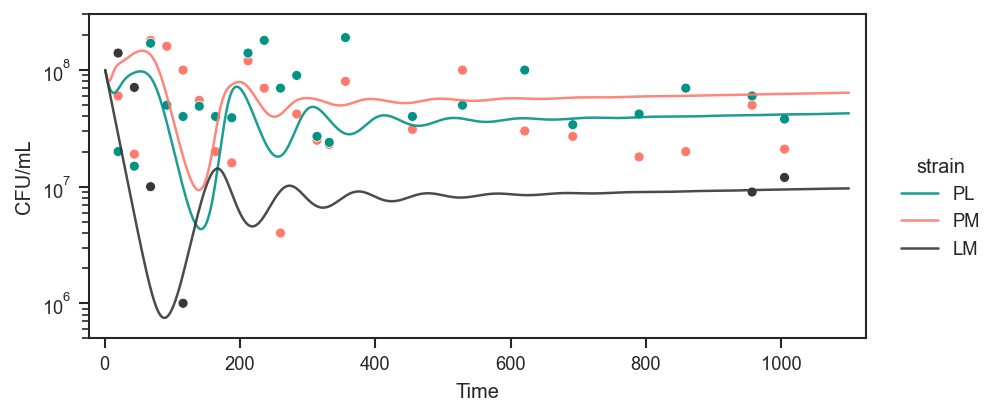

In [7]:
cp = sns.relplot(data=b,
                 x='time',
                 y='CFU/mL model',
                 hue='strain',
                 kind='line',
                 # col='vial',
                 # col_wrap=2,
                 errorbar=None,
                 height=3, aspect=2,
                 alpha=0.9,
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 hue_order=['PL', 'PM', 'LM'],
                 legend=True
                )
# cp.map_dataframe(sns.scatterplot,
#                  x='time',
#                  y='CFU/mL interpolation',
#                  hue='strain',
#                  palette=['xkcd:teal',
#                           'xkcd:salmon',
#                           'xkcd:dark grey'],
#                  hue_order=['PL', 'PM', 'LM'],
#                  alpha=0.6
#                 )
cp.map_dataframe(sns.scatterplot,
                 x='time',
                 y='CFU/mL',
                 hue='strain',
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 hue_order=['PL', 'PM', 'LM'],
                 # alpha=0.6
                )

cp.set(
       yscale='log',
       ylabel='CFU/mL',
       xlabel='Time',
       ylim=(5E5, 3E8),
       xlim=(-23, 1125),
       # xticks=[0, 200, 400]
      )
cp.set_titles("",
              fontsize=9)
plt.subplots_adjust(wspace=0.1, hspace=0.1)

sns.despine(top=False,
            right=False)

plt.savefig('model_long.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('model_long.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

In [8]:
def gof(g):
    o = np.log10(g['CFU/mL'])
    p = np.log10(g['CFU/mL model'])
    r = p - o
    return pd.Series({'n': len(o),
                      'R2': 1 - (r ** 2).sum() / ((o - o.mean()) ** 2).sum(),
                      'RMSE (log10)': np.sqrt((r ** 2).mean()),
                      'MAE (log10)': r.abs().mean(),
                      'bias (log10)': r.mean(),
                      'fold error': 10 ** np.sqrt((r ** 2).mean()),
                      'pearson r': o.corr(p),
                      'spearman rho': o.rank().corr(p.rank()),
                      'null RMSE (log10)': o.std(ddof=0)})

v = b[['time', 'strain', 'CFU/mL', 'CFU/mL model']].dropna()
v = v[(v['CFU/mL'] > 0) & (v['CFU/mL model'] > 0)]

fit = pd.concat([v.groupby('strain')[['CFU/mL', 'CFU/mL model']].apply(gof),
                 gof(v).to_frame('all').T])
fit.round(3)

,n,R2,RMSE (log10),MAE (log10),bias (log10),fold error,pearson r,spearman rho,null RMSE (log10)
LM,6.0,0.125,0.647,0.505,-0.417,4.435,0.700,0.600,0.692
PL,23.0,-1.691,0.484,0.388,-0.206,3.046,-0.088,-0.271,0.295
PM,23.0,-0.527,0.471,0.397,0.142,2.957,0.019,-0.006,0.381
all,52.0,-0.338,0.500,0.406,-0.076,3.161,0.329,-0.009,0.432


In [9]:
m = pd.read_csv('../data/model/inoculum_sweep.tsv', sep='\t')

m['init_As'] = m['init_As'] * 1E7
m['init_Bs'] = m['init_Bs'] * 1E7
m['init_Cs'] = m['init_Cs'] * 1E7
m['total'] = (m['LM'] + m['PM'] + m['PL']) * 1E7

n = m[m['time'] == 1100]

/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


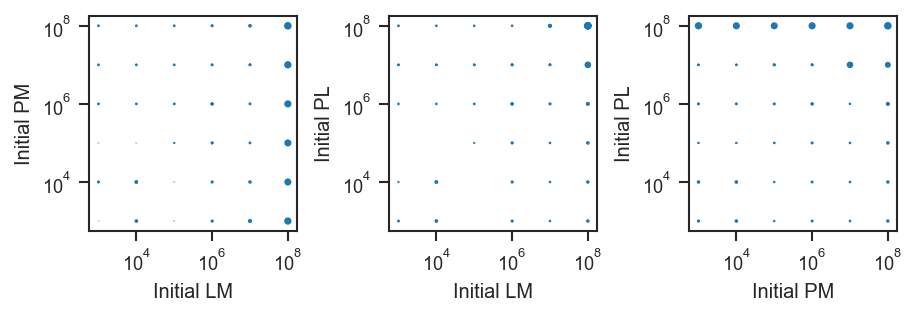

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(6, 2),
                         constrained_layout=True)

ax = axes[0]

ax.scatter(n['init_As'], n['init_Bs'], s=np.log10(n['total']))

ax.set_xlabel('Initial LM')
ax.set_ylabel('Initial PM')

ax.set_xscale('log')
ax.set_yscale('log')

ax = axes[1]

ax.scatter(n['init_As'], n['init_Cs'], s=np.log10(n['total']))

ax.set_xlabel('Initial LM')
ax.set_ylabel('Initial PL')

ax.set_xscale('log')
ax.set_yscale('log')

ax = axes[2]

ax.scatter(n['init_Bs'], n['init_Cs'], s=np.log10(n['total']))

ax.set_xlabel('Initial PM')
ax.set_ylabel('Initial PL')

ax.set_xscale('log')
ax.set_yscale('log');

In [11]:
m = pd.read_csv('../data/model/ab_gamma_no_plasmid.tsv', sep='\t')

m['gamma'] = m['gamma'].round(3)

m['LM'] = m['LM'] * 1E7
m['PM'] = m['PM'] * 1E7
m['PL'] = m['PL'] * 1E7
m['total'] = (m['LM'] + m['PM'] + m['PL'])

n = m[m['time'] == m['time'].max()]

In [12]:
nt = m[m['total'] < 100].groupby(['run', 'Ab_init', 'gamma'])['time'].min().to_frame().reindex(m[m['time'] == 1][['run', 'Ab_init', 'gamma']])

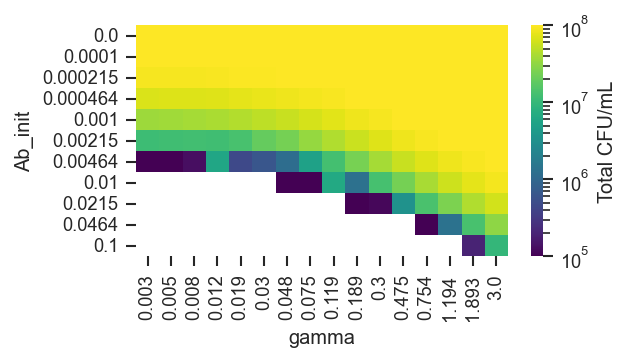

In [13]:
plt.figure(figsize=(4, 2))

sns.heatmap(data=n.pivot_table(index='Ab_init', columns='gamma', values='total'),
    cmap='viridis',
    norm=LogNorm(vmin=1E5, vmax=1E8),
    cbar_kws={'label': 'Total CFU/mL'}
);

/tmp/ipykernel_2323744/1501914274.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('cividis')


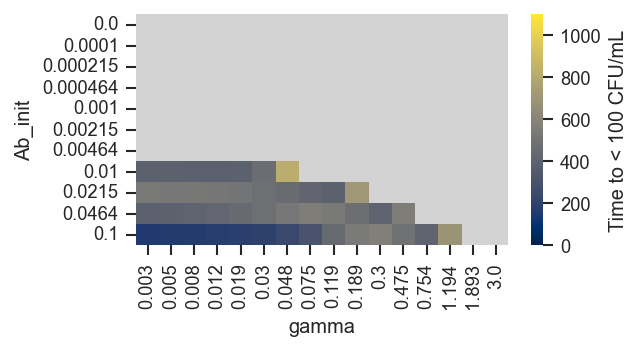

In [14]:
plt.figure(figsize=(4, 2))

cmap = plt.cm.get_cmap('cividis')
cmap.set_under('lightgrey')

sns.heatmap(data=nt.fillna(-1).pivot_table(index='Ab_init', columns='gamma', values='time'),
    cmap=cmap,
    vmin=0, vmax=m['time'].max(),
    cbar_kws={'label': 'Time to < 100 CFU/mL'}
);

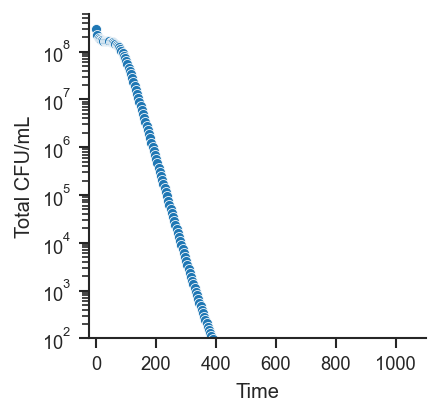

In [15]:
rp = sns.relplot(data=m[(m['Ab_init'] == 0.01) &
                   (m['gamma'] == 0.019)],
            x='time',
            y='total',
            height=3, aspect=1)

rp.set(yscale='log',
       ylabel='Total CFU/mL',
       xlabel='Time',
       ylim=(100, 6E8),
       xlim=(-23, 1100));

In [16]:
m = pd.read_csv('../data/model/epsilon_all_sensitive.tsv', sep='\t')

for strain in ['As',
               'Bs',
               'Cs']:
    m[strain] = m[strain] * 1E7

m['total'] = m[['As', 'Bs', 'Cs']].sum(axis=1)

m = m.rename(columns={'As': 'LM',
                      'Bs': 'PM',
                      'Cs': 'PL'})

m['log(epsilon)'] = np.log10(m['epsilon'])

n = m[m['time'] == m['time'].max()]

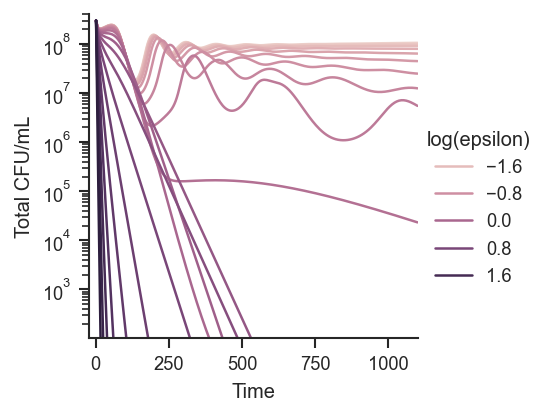

In [17]:
rp = sns.relplot(data=m,
                 x='time',
                 y='total',
                 hue='log(epsilon)',
                 kind='line',
                 height=3, aspect=1)

rp.set(yscale='log',
       ylabel='Total CFU/mL',
       xlabel='Time',
       ylim=(101, 4E8),
       xlim=(-23, 1100));

In [18]:
m = pd.read_csv('../data/model/epsilon_no_transfer.tsv', sep='\t')

for strain in ['Ar',
               'Bs',
               'Cs']:
    m[strain] = m[strain] * 1E7

m['total'] = m[['Ar', 'Bs', 'Cs']].sum(axis=1)

m = m.rename(columns={'Ar': 'LM',
                      'Bs': 'PM',
                      'Cs': 'PL'})

m['log(epsilon)'] = np.log10(m['epsilon'])

n = m[m['time'] == m['time'].max()]

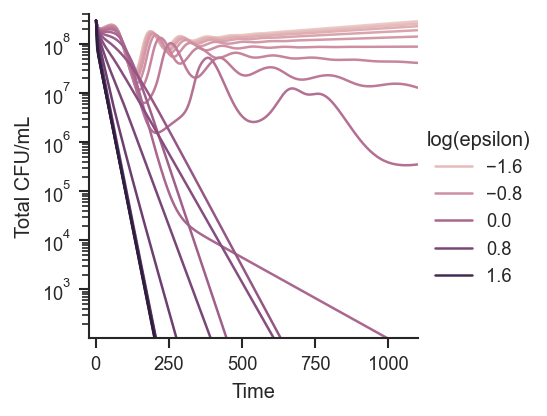

In [19]:
rp = sns.relplot(data=m,
                 x='time',
                 y='total',
                 hue='log(epsilon)',
                 kind='line',
                 height=3, aspect=1)

rp.set(yscale='log',
       ylabel='Total CFU/mL',
       xlabel='Time',
       ylim=(101, 4E8),
       xlim=(-23, 1100));

In [20]:
m = pd.read_csv('../data/model/epsilon_eta_plasmid.tsv', sep='\t')

for strain in ['Ar',
               'Bs', 'Br',
               'Cs', 'Cr']:
    m[strain] = m[strain] * 1E7

m['total'] = m[['Ar', 'Bs', 'Br', 'Cs', 'Cr']].sum(axis=1)
m['total_R'] = m[['Br', 'Cr']].sum(axis=1)

m['log(epsilon)'] = np.log10(m['epsilon'])
m['epsilon'] = m['epsilon'].round(3)
m['eta'] = m['eta'].round(5)

n = m[m['time'] == m['time'].max()]

In [21]:
nt = m[m['total'] < 1000].groupby(['run', 'epsilon', 'eta'])['time'].min().to_frame().reindex(m[m['time'] == 1][['run', 'epsilon', 'eta']])

In [22]:
kt = m[m['total_R'] > 1E7].groupby(['run', 'epsilon', 'eta'])['time'].min().to_frame().reindex(m[m['time'] == 1][['run', 'epsilon', 'eta']])

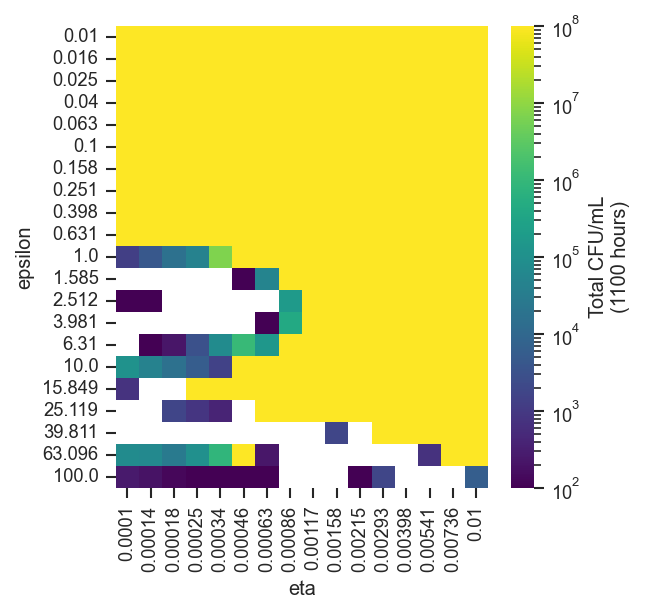

In [23]:
plt.figure(figsize=(4, 4))

sns.heatmap(data=n.pivot_table(index='epsilon', columns='eta', values='total'),
    cmap='viridis',
    norm=LogNorm(vmin=100, vmax=1E8),
    cbar_kws={'label': 'Total CFU/mL\n(1100 hours)'}
);

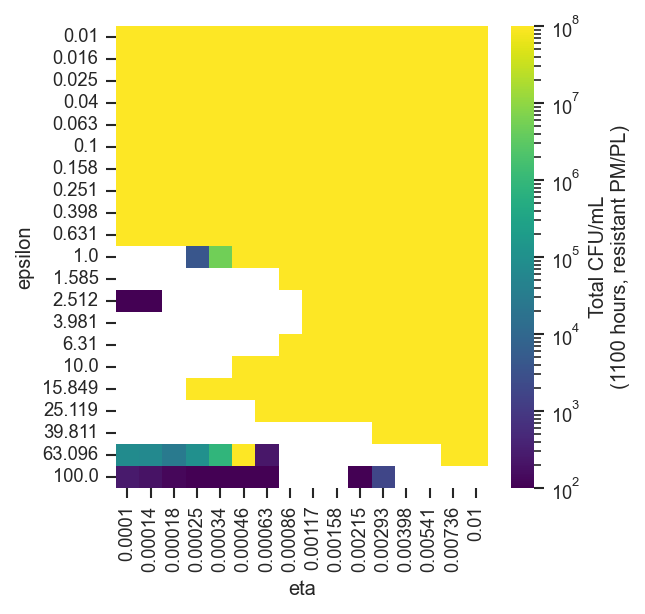

In [24]:
plt.figure(figsize=(4, 4))

sns.heatmap(data=n.pivot_table(index='epsilon', columns='eta', values='total_R'),
    cmap='viridis',
    norm=LogNorm(vmin=100, vmax=1E8),
    cbar_kws={'label': 'Total CFU/mL\n(1100 hours, resistant PM/PL)'}
);

/tmp/ipykernel_2323744/4015704268.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('cividis')


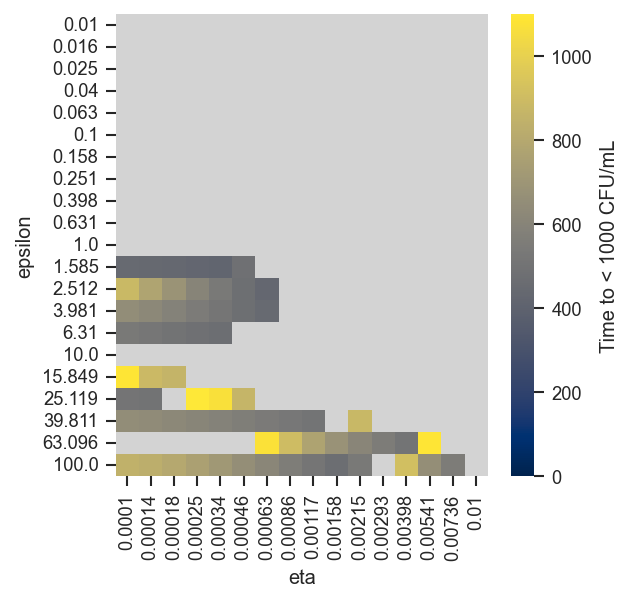

In [25]:
plt.figure(figsize=(4, 4))

cmap = plt.cm.get_cmap('cividis')
cmap.set_under('lightgrey')

sns.heatmap(data=nt.fillna(-1).pivot_table(index='epsilon', columns='eta', values='time'),
    cmap=cmap,
    vmin=0, vmax=m['time'].max(),
    cbar_kws={'label': 'Time to < 1000 CFU/mL'}
);

/tmp/ipykernel_2323744/4089409622.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('cividis')


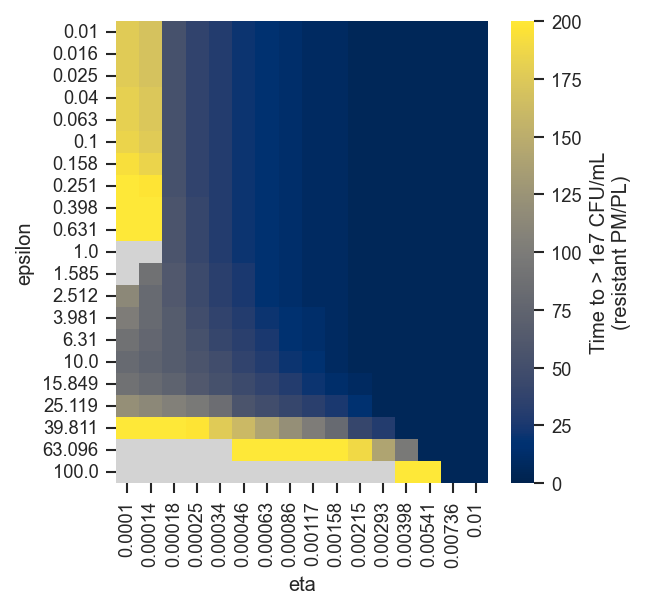

In [26]:
plt.figure(figsize=(4, 4))

cmap = plt.cm.get_cmap('cividis')
cmap.set_under('lightgrey')

sns.heatmap(data=kt.fillna(-1).pivot_table(index='epsilon', columns='eta', values='time'),
    cmap=cmap,
    vmin=0, vmax=200,
    cbar_kws={'label': 'Time to > 1e7 CFU/mL\n(resistant PM/PL)'}
);

In [27]:
files = {'no_plasmid': '../data/model/exp_match_no_plasmid.tsv',
         'PVB': '../data/model/exp_match_PVB.tsv',
         'PVI': '../data/model/exp_match_PVI.tsv',
         'slow': '../data/model/exp_match_slow_conj.tsv',
         'strong': '../data/model/exp_match_strong_drug.tsv'}

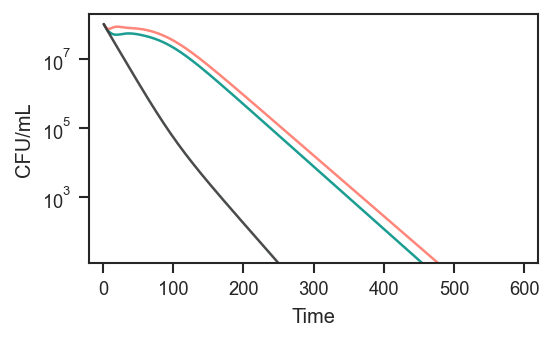

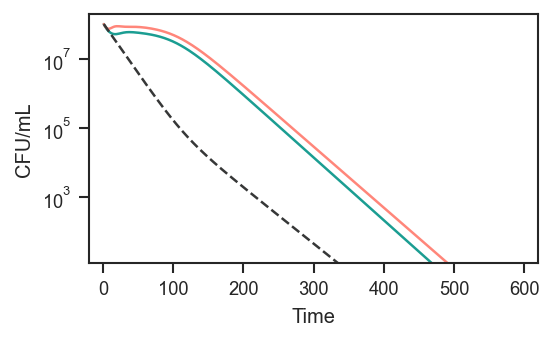

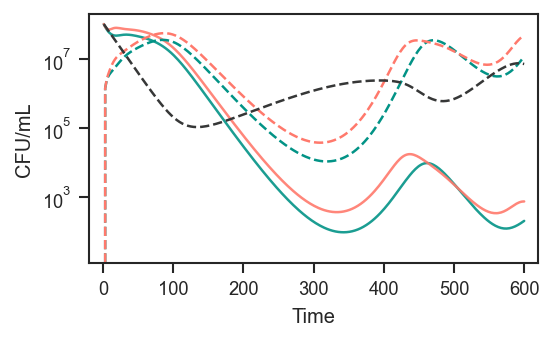

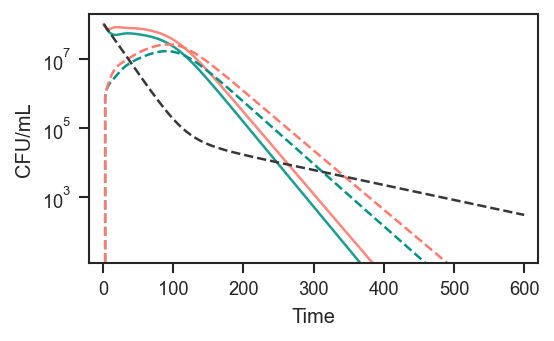

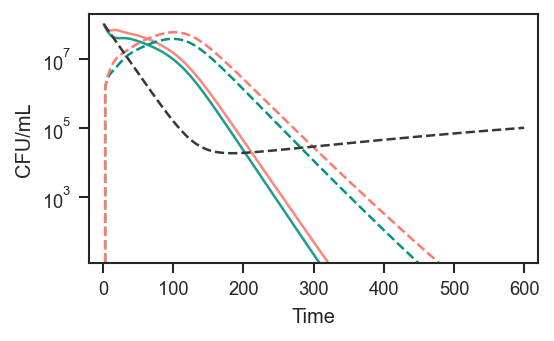

In [28]:
for name, fname in files.items():
    m = pd.read_csv(fname, sep='\t')
    
    for strain in ['As', 'Ar',
                   'Bs', 'Br',
                   'Cs', 'Cr']:
        m[strain] = m[strain] * 1E7
    
    m['total'] = m[['As', 'Ar',
                    'Bs', 'Br',
                    'Cs', 'Cr']].sum(axis=1)
    
    m = m.rename(columns={'As': 'LM',
                          'Bs': 'PM',
                          'Cs': 'PL',
                          'Ar': 'LM-plasmid',
                          'Br': 'PM-plasmid',
                          'Cr': 'PL-plasmid'})

    c = m.set_index('time')[['LM', 'LM-plasmid',
                             'PM', 'PM-plasmid',
                             'PL', 'PL-plasmid']].stack(
            ).reset_index(
            ).rename(columns={'level_1': 'strain',
                     0: 'CFU/mL'})

    cp = sns.relplot(data=c,
                     x='time',
                     y='CFU/mL',
                     hue='strain',
                     kind='line',
                     # col='vial',
                     # col_wrap=2,
                     errorbar=None,
                     height=2.5, aspect=1.5,
                     alpha=0.9,
                     palette=['xkcd:teal',
                              'xkcd:salmon',
                              'xkcd:dark grey'],
                     hue_order=['PL', 'PM', 'LM'],
                     legend=False
                    )
    cp.map_dataframe(sns.lineplot,
        x='time',
         y='CFU/mL',
         hue='strain',
         palette=['xkcd:teal', 'xkcd:salmon', 'xkcd:dark grey'],
         hue_order=['PL-plasmid', 'PM-plasmid', 'LM-plasmid'],
         linestyle='--')
    
    cp.set(yscale='log',
           ylabel='CFU/mL',
           xlabel='Time',
           ylim=(12, 1.9E8),
           xlim=(-20, 620),
           # xticks=[0, 200, 400]
          )
    cp.set_titles("",
                  fontsize=9)
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    
    sns.despine(top=False,
                right=False)

    plt.savefig(f'model_{name}.png',
                dpi=300,
                bbox_inches='tight',
                transparent=True
               )
    plt.savefig(f'model_{name}.svg',
                dpi=300, bbox_inches='tight',
                transparent=True);

In [29]:
EPSILON_MIN = 0.251

s = pd.read_csv('../data/model/epsilon_all_sensitive.tsv', sep='\t')

s['LM'] = s['As'] * 1E7
s['PM'] = s['Bs'] * 1E7
s['PL'] = s['Cs'] * 1E7
s['total_R'] = 0.0
s['eta'] = 0.0

p = pd.read_csv('../data/model/epsilon_eta_plasmid.tsv', sep='\t')

p['LM'] = p['Ar'] * 1E7
p['PM'] = (p['Bs'] + p['Br']) * 1E7
p['PL'] = (p['Cs'] + p['Cr']) * 1E7
p['total_R'] = (p['Br'] + p['Cr']) * 1E7

h = pd.concat([s[['epsilon', 'eta', 'time', 'LM', 'PM', 'PL', 'total_R']],
               p[['epsilon', 'eta', 'time', 'LM', 'PM', 'PL', 'total_R']]],
              ignore_index=True)

h['total'] = h[['LM', 'PM', 'PL']].sum(axis=1)
h['log(epsilon)'] = np.log10(h['epsilon'])
h['epsilon'] = h['epsilon'].round(3)
h['eta'] = h['eta'].round(5)

h = h[h['epsilon'] >= EPSILON_MIN]

hn = h[h['time'] == h['time'].max()]
hmin = h.groupby(['epsilon', 'eta'])[['LM', 'PM', 'PL']].min().min(axis=1).rename('min strain').reset_index()

scenarios = {'drug no plasmid': (1.585, 0.0),
             'PVI': (1.585, 0.00086),
             'slow conjugation': (1.585, 0.00046),
             'strong drug': (2.512, 0.00086)}
scenarios_index = {'drug no plasmid': '1',
             'PVI': '2',
             'slow conjugation': '3',
             'strong drug': '4'}

hmin['scenario'] = ''

for name, (e, n) in scenarios.items():
    hmin.loc[(hmin['epsilon'] == e) & (hmin['eta'] == n), 'scenario'] = scenarios_index[name]

hm = hmin.pivot(index='epsilon', columns='eta', values='min strain')
hlab = hmin.pivot(index='epsilon',
                  columns='eta',
                  values='scenario')


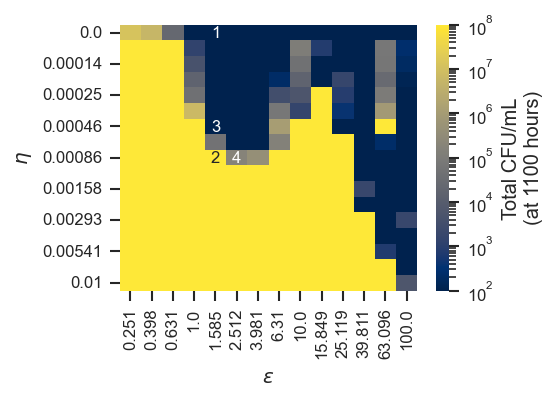

In [30]:
with plt.rc_context({'xtick.labelsize': 8, 'ytick.labelsize': 8}):
    
    plt.figure(figsize=(3.2, 2.3))
    
    cmap = matplotlib.colormaps.get_cmap('cividis')
    # cmap.set_under('blue')
    
    sns.heatmap(data=hn.pivot_table(columns='epsilon', index='eta', values='total').replace(0, 1),
        cmap=cmap,
        norm=LogNorm(vmin=100, vmax=1E8),
        cbar_kws={'label': 'Total CFU/mL\n(at 1100 hours)'},
        annot=hlab.T, fmt='',
        annot_kws={'size': 8}
    )
    
    plt.ylabel(r'$\eta$')
    plt.xlabel(r'$\epsilon$')
    
plt.savefig('model_sweep.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('model_sweep.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

In [31]:
# manuscript: goodness of fit quoted for the held-out TriComm KAN run
print(fit.loc['all', ['pearson r', 'spearman rho', 'R2', 'RMSE (log10)', 'MAE (log10)']].round(3).to_string())

pearson r       0.329
spearman rho   -0.009
R2             -0.338
RMSE (log10)    0.500
MAE (log10)     0.406
